In [54]:
import kagglehub
import pandas as pd
import numpy as np
import joblib
import os

# Creeating CSV given the path of the images
path = str(kagglehub.dataset_download("moltean/fruits"))
print("Path to dataset files:", path)

def create_csv(dataset_type):
    dataset_path = f'{path}/fruits-360_100x100/fruits-360/{dataset_type}'
    image_paths = []
    labels = []

    for label in os.listdir(dataset_path):
        label_path = os.path.join(dataset_path, label)
        if os.path.isdir(label_path):
            for image_name in os.listdir(label_path):
                if image_name.endswith('.jpg'):
                    image_paths.append(os.path.join(label, image_name))
                    labels.append(label)

    df = pd.DataFrame({
        'image': image_paths,
        'label': labels
    })

    csv_filename = f'fruits_{dataset_type.lower()}.csv'
    df.to_csv(csv_filename, index=False)
    print(f"{dataset_type} CSV saved at: {os.path.join(os.getcwd(), csv_filename)}")

create_csv('Training')
create_csv('Test')

train_csv = os.path.join(os.getcwd(), 'fruits_training.csv')
test_csv = os.path.join(os.getcwd(), 'fruits_test.csv')

# Load them into DataFrames
train_df = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)

# Check the first few rows
print(train_df.head())
print(test_df.head())

def limit_classes(df, num_classes=50, samples_per_class=None, random_state=42):
    unique_classes = df["label"].unique()
    np.random.seed(random_state)

    selected_classes = np.random.choice(unique_classes, num_classes, replace=False)
    df = df[df["label"].isin(selected_classes)]

    if samples_per_class:
        df = df.groupby("label").apply(
            lambda x: x.sample(n=min(samples_per_class, len(x)), random_state=random_state)
        ).reset_index(drop=True)

    return df

imgPerClass = 50

train_df = limit_classes(train_df, samples_per_class=imgPerClass)
test_df = limit_classes(test_df, samples_per_class=imgPerClass)

Path to dataset files: /root/.cache/kagglehub/datasets/moltean/fruits/versions/54
Training CSV saved at: /root/python/Fruit-Classification/fruits_training.csv
Test CSV saved at: /root/python/Fruit-Classification/fruits_test.csv
                       image       label
0  Cucumber 5/r0_124_100.jpg  Cucumber 5
1    Cucumber 5/r1_2_100.jpg  Cucumber 5
2    Cucumber 5/r2_1_100.jpg  Cucumber 5
3  Cucumber 5/r0_168_100.jpg  Cucumber 5
4  Cucumber 5/r2_201_100.jpg  Cucumber 5
                       image       label
0  Cucumber 5/r2_115_100.jpg  Cucumber 5
1  Cucumber 5/r1_135_100.jpg  Cucumber 5
2  Cucumber 5/r0_175_100.jpg  Cucumber 5
3  Cucumber 5/r2_111_100.jpg  Cucumber 5
4   Cucumber 5/r1_71_100.jpg  Cucumber 5


/tmp/ipykernel_167969/1610652148.py:55: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("label").apply(
/tmp/ipykernel_167969/1610652148.py:55: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("label").apply(


In [55]:
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc, roc_auc_score, make_scorer, f1_score
from concurrent.futures import ProcessPoolExecutor
from sklearn.preprocessing import label_binarize, LabelEncoder
from functools import partial
from sklearn.model_selection import StratifiedKFold, cross_val_score
from PIL import Image
import numpy as np
import os

size = (64, 64)

def process_image(row, base_path, crop_size):
    image_path = os.path.join(base_path, row['image'])
    img = Image.open(image_path).convert('RGB')
    img = img.resize(crop_size)
    img_array = np.array(img, dtype=np.float32) / 255.0
    label = row['label']
    return img_array, label


def load_parallel(csv_df, base_path, crop_size=size, n_jobs=30):
    rows = csv_df.to_dict("records")
    n_samples = len(rows)
    
    X = np.empty((n_samples, crop_size[0], crop_size[1], 3), dtype=np.float32)
    y = [None] * n_samples

    with ProcessPoolExecutor(max_workers=n_jobs) as executor:
        func = partial(process_image, base_path=base_path, crop_size=crop_size)
        for i, (img_array, label) in enumerate(executor.map(func, rows, chunksize=50)):
            X[i] = img_array
            y[i] = label

    return X, np.array(y)


base_path_train = os.path.join(path, "fruits-360_100x100/fruits-360/Training")
X_train, y_train = load_parallel(train_df, base_path_train)

base_path_val = os.path.join(path, "fruits-360_100x100/fruits-360/Test")
X_val, y_val = load_parallel(test_df, base_path_val)

print("Train:", X_train.shape, "Val:", X_val.shape)
print("Unique train labels:", np.unique(y_train))
print("Unique val labels:", np.unique(y_val))

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat   = X_val.reshape(X_val.shape[0], -1)

# encode labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)


Train: (2500, 64, 64, 3) Val: (2500, 64, 64, 3)
Unique train labels: ['Apple 14' 'Apple 5' 'Apple Golden 1' 'Apple Red Yellow 1'
 'Apple Red Yellow 2' 'Avocado ripe 1' 'Banana 4' 'Banana Lady Finger 1'
 'Beans 1' 'Beetroot 1' 'Blackberrie 1' 'Carambula 1' 'Carrot 1'
 'Cauliflower 1' 'Cherimoya 1' 'Cherry 3' 'Cherry 4' 'Cherry Sour 1'
 'Cherry Wax Red 1' 'Cherry Wax Red 2' 'Cherry Wax Yellow 1'
 'Cherry Wax not ripen 2' 'Chestnut 1' 'Cucumber 7' 'Eggplant long 1'
 'Ginger Root 1' 'Gooseberry 1' 'Granadilla 1' 'Grape Pink 1'
 'Grape White 3' 'Kaki 1' 'Mandarine 1' 'Mango Red 1'
 'Melon Piel de Sapo 1' 'Nut 1' 'Nut 3' 'Onion Red Peeled 1'
 'Onion White 1' 'Passion Fruit 1' 'Pear 6' 'Pear 7' 'Pear Forelle 1'
 'Plum 1' 'Plum 3' 'Pomelo Sweetie 1' 'Potato Red 1' 'Potato Sweet 1'
 'Strawberry Wedge 1' 'Tomato Cherry Yellow 1' 'Zucchini 1']
Unique val labels: ['Apple 14' 'Apple 5' 'Apple Golden 1' 'Apple Red Yellow 1'
 'Apple Red Yellow 2' 'Avocado ripe 1' 'Banana 4' 'Banana Lady Finger 1'
 'B

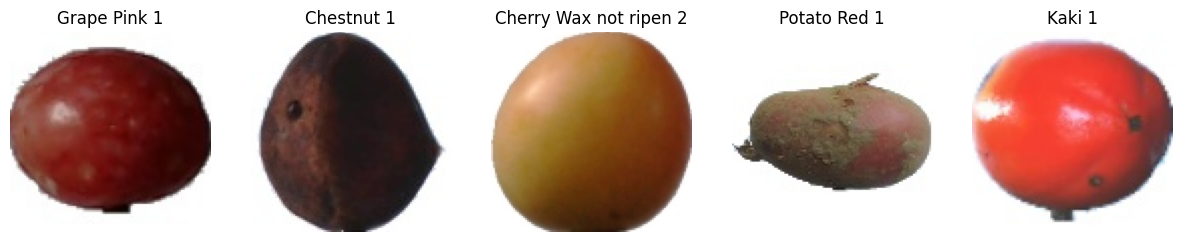

In [56]:
import matplotlib.pyplot as plt
from PIL import Image
import os
sample_rows = train_df.sample(5, random_state=42)

base_path_train = os.path.join(path, "fruits-360_100x100/fruits-360/Training")

plt.figure(figsize=(15, 5))

for i, (_, row) in enumerate(sample_rows.iterrows(), 1):
    img_path = os.path.join(base_path_train, row['image'])
    img = Image.open(img_path).convert('RGB')
    
    plt.subplot(1, 5, i)
    plt.imshow(img)
    plt.title(row['label'])
    plt.axis('off')

plt.show()


In [57]:
from sklearn.decomposition import PCA


# Apply PCA and overwrite X_train/X_val
n_components = 0.95
pca = PCA(n_components=n_components, random_state=42)
pca_X_train = pca.fit_transform(X_train_flat)
pca_X_val = pca.transform(X_val_flat)

print("Original shape after flattening:", X_train.shape[0], "features:", X_train.shape[1])
print("PCA Shape:", pca_X_train.shape[0], "features:", pca_X_train.shape[1])

Original shape after flattening: 2500 features: 64
PCA Shape: 2500 features: 105


In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt_clf = DecisionTreeClassifier(max_depth=20, 
                                min_samples_leaf=2,
                                random_state=42)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

scorers = {
    "accuracy": make_scorer(accuracy_score),
    "f1_macro": make_scorer(f1_score, average="macro")
}

for metric_name, scorer in scorers.items():
    scores = cross_val_score(dt_clf, X_train_flat, y_train_enc, cv=skf, scoring=scorer, n_jobs=-1)
    print(f"{metric_name}: {scores.mean():.4f} ± {scores.std():.4f}")

dt_clf.fit(X_train_flat, y_train_enc)
joblib.dump(dt_clf, "dt_model.joblib")    

/usr/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)


accuracy: 0.7564 ± 0.0147


Validation accuracy: 0.7328
                      precision    recall  f1-score   support

            Apple 14       0.80      0.74      0.77        50
             Apple 5       0.88      0.88      0.88        50
      Apple Golden 1       0.71      0.58      0.64        50
  Apple Red Yellow 1       0.83      0.76      0.79        50
  Apple Red Yellow 2       0.63      0.88      0.73        50
      Avocado ripe 1       0.94      1.00      0.97        50
            Banana 4       0.88      0.90      0.89        50
Banana Lady Finger 1       0.43      0.58      0.49        50
             Beans 1       1.00      0.98      0.99        50
          Beetroot 1       0.90      0.56      0.69        50
       Blackberrie 1       0.60      0.76      0.67        50
         Carambula 1       0.44      0.54      0.49        50
            Carrot 1       0.93      1.00      0.96        50
       Cauliflower 1       0.50      0.30      0.38        50
         Cherimoya 1       0.70      0.70

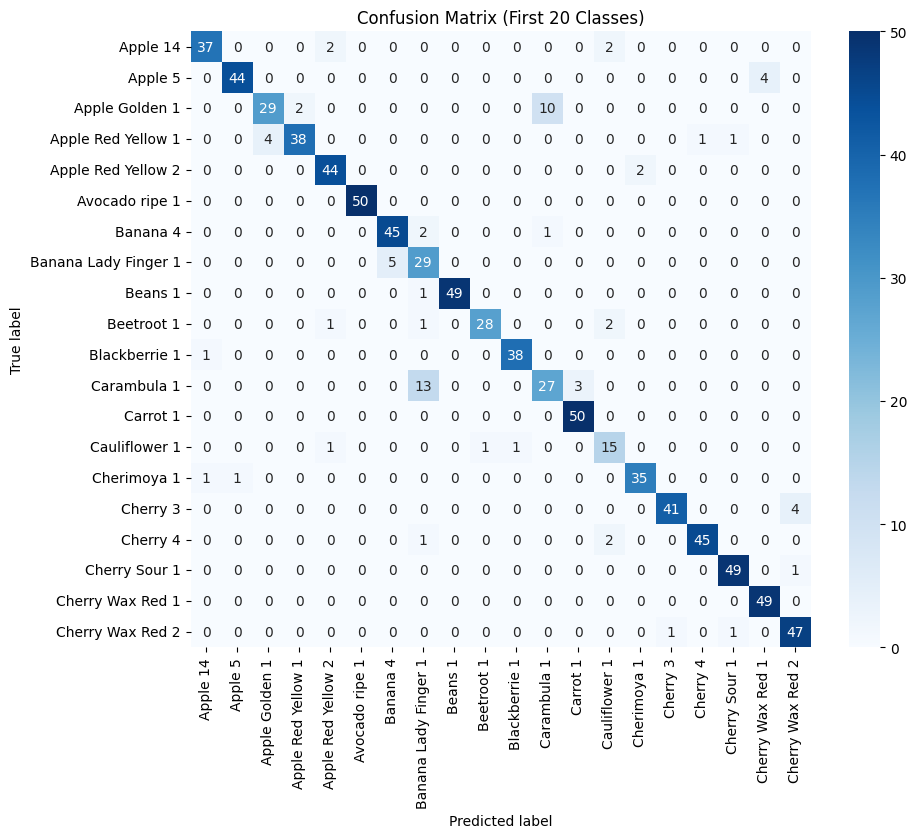

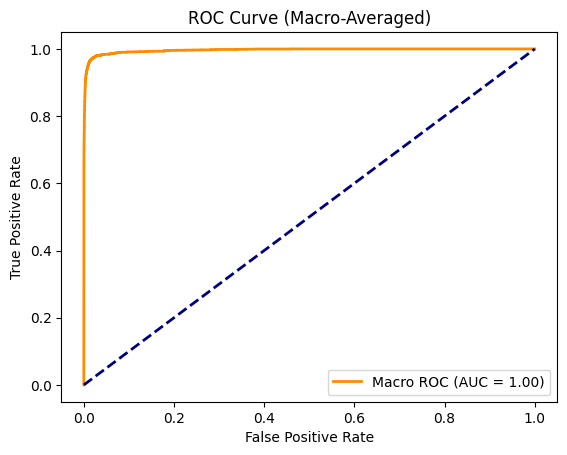

In [ ]:
saved_model_name = "dt_model"

saved_model = joblib.load(f"{saved_model_name}.joblib")
y_pred = saved_model.predict(X_val_flat)
acc = accuracy_score(y_val_enc, y_pred)

# Classification report
print(f"Validation accuracy: {acc:.4f}")
selected_classes = le.classes_[:20]
selected_labels = [le.transform([c])[0] for c in selected_classes]
print(classification_report(
    y_val_enc,
    y_pred,
    labels=selected_labels,
    target_names=selected_classes
))

subset_classes = le.classes_[:20]

mat_subset = confusion_matrix(
    y_val_enc, y_pred, 
    labels=range(len(subset_classes))
)

# Confusion matrix 
plt.figure(figsize=(10, 8))
sns.heatmap(mat_subset, cmap="Blues", annot=True, fmt="d", 
            xticklabels=subset_classes, 
            yticklabels=subset_classes)

plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix (First 20 Classes)')
plt.show()

# ROC Curve
y_val_bin = label_binarize(y_val_enc, classes=np.arange(len(le.classes_)))
y_proba = saved_model.predict_proba(X_val_flat)

fpr, tpr, _ = roc_curve(y_val_bin.ravel(), y_proba.ravel())
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"Macro ROC (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Macro-Averaged)")
plt.legend(loc="lower right")
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
lr_clf = LogisticRegression(max_iter=200, multi_class='multinomial', solver='saga', n_jobs=-1)              

for metric_name, scorer in scorers.items():
    scores = cross_val_score(lr_clf, pca_X_train, y_train_enc, cv=skf, scoring=scorer, n_jobs=-1)
    print(f"{metric_name}: {scores.mean():.4f} ± {scores.std():.4f}")

lr_clf.fit(pca_X_train, y_train_enc)
joblib.dump(lr_clf, "lr_model.joblib")

/root/python/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/root/python/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/root/python/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/root/python/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was 

accuracy: 0.9680 ± 0.0052


/root/python/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/root/python/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/root/python/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/root/python/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it

KeyboardInterrupt: 

Validation accuracy: 0.9092
                      precision    recall  f1-score   support

            Apple 14       0.98      1.00      0.99        50
             Apple 5       0.89      1.00      0.94        50
      Apple Golden 1       1.00      0.78      0.88        50
  Apple Red Yellow 1       1.00      1.00      1.00        50
  Apple Red Yellow 2       0.98      0.84      0.90        50
      Avocado ripe 1       1.00      1.00      1.00        50
            Banana 4       0.89      1.00      0.94        50
Banana Lady Finger 1       1.00      0.52      0.68        50
             Beans 1       1.00      1.00      1.00        50
          Beetroot 1       0.83      0.50      0.62        50
       Blackberrie 1       0.60      0.98      0.74        50
         Carambula 1       0.83      1.00      0.91        50
            Carrot 1       0.78      1.00      0.88        50
       Cauliflower 1       0.84      0.96      0.90        50
         Cherimoya 1       0.80      0.98

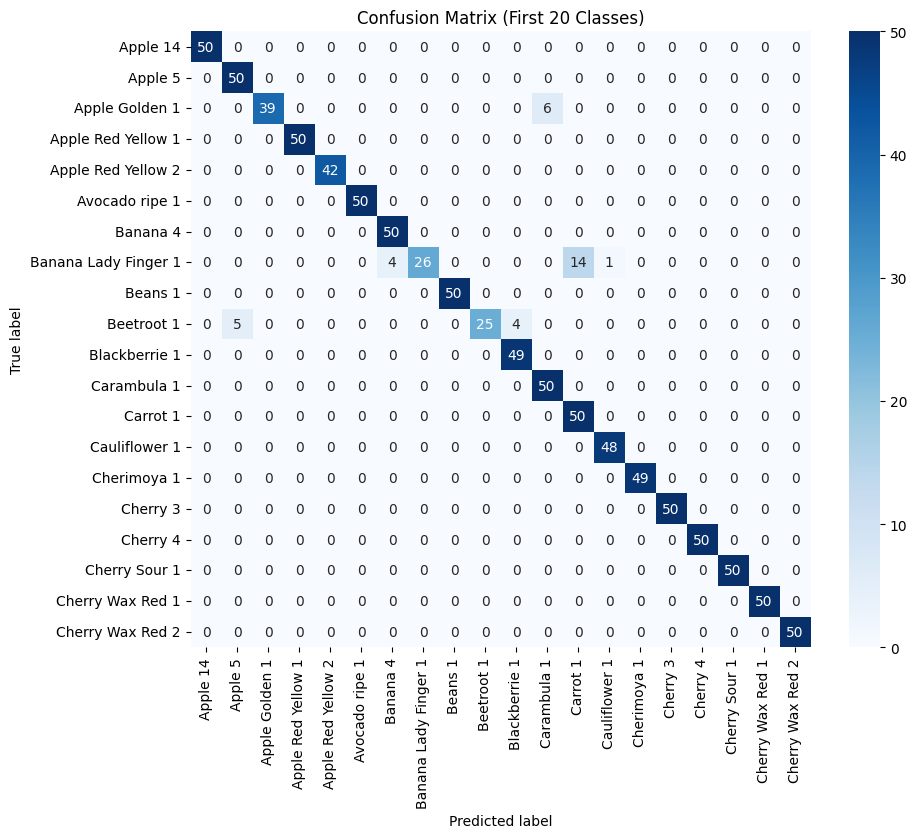

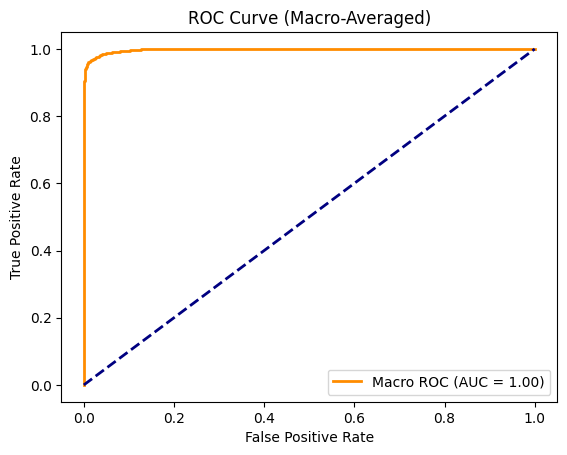

In [ ]:
saved_model_name = "lr_model"

saved_model = joblib.load(f"{saved_model_name}.joblib")
y_pred = saved_model.predict(pca_X_val)
acc = accuracy_score(y_val_enc, y_pred)

# Classification report
print(f"Validation accuracy: {acc:.4f}")
selected_classes = le.classes_[:20]
selected_labels = [le.transform([c])[0] for c in selected_classes]
print(classification_report(
    y_val_enc,
    y_pred,
    labels=selected_labels,
    target_names=selected_classes
))

subset_classes = le.classes_[:20]

mat_subset = confusion_matrix(
    y_val_enc, y_pred, 
    labels=range(len(subset_classes))
)

# Confusion matrix 
plt.figure(figsize=(10, 8))
sns.heatmap(mat_subset, cmap="Blues", annot=True, fmt="d", 
            xticklabels=subset_classes, 
            yticklabels=subset_classes)

plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix (First 20 Classes)')
plt.show()

# ROC Curve
y_val_bin = label_binarize(y_val_enc, classes=np.arange(len(le.classes_)))
y_proba = saved_model.predict_proba(pca_X_val)

fpr, tpr, _ = roc_curve(y_val_bin.ravel(), y_proba.ravel())
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"Macro ROC (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Macro-Averaged)")
plt.legend(loc="lower right")
plt.show()



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier(n_neighbors=5)   

for metric_name, scorer in scorers.items():
    scores = cross_val_score(knn_clf, X_train_flat, y_train_enc, cv=skf, scoring=scorer, n_jobs=-1)
    print(f"{metric_name}: {scores.mean():.4f} ± {scores.std():.4f}")

knn_clf.fit(X_train_flat, y_train_enc)
joblib.dump(knn_clf, "knn_model.joblib")

kNN Accuracy: 0.8412
                        precision    recall  f1-score   support

              Apple 14       0.54      0.98      0.70        50
               Apple 5       1.00      1.00      1.00        50
        Apple Golden 1       0.81      0.88      0.85        50
    Apple Red Yellow 1       1.00      0.56      0.72        50
    Apple Red Yellow 2       0.93      0.82      0.87        50
        Avocado ripe 1       0.64      0.90      0.75        50
              Banana 4       0.93      0.86      0.90        50
  Banana Lady Finger 1       0.86      0.48      0.62        50
               Beans 1       1.00      1.00      1.00        50
            Beetroot 1       0.67      0.58      0.62        50
         Blackberrie 1       0.95      0.78      0.86        50
           Carambula 1       0.98      1.00      0.99        50
              Carrot 1       0.72      1.00      0.84        50
         Cauliflower 1       0.93      0.82      0.87        50
           Cherimo

Validation accuracy: 0.8412
                      precision    recall  f1-score   support

            Apple 14       0.54      0.98      0.70        50
             Apple 5       1.00      1.00      1.00        50
      Apple Golden 1       0.81      0.88      0.85        50
  Apple Red Yellow 1       1.00      0.56      0.72        50
  Apple Red Yellow 2       0.93      0.82      0.87        50
      Avocado ripe 1       0.64      0.90      0.75        50
            Banana 4       0.93      0.86      0.90        50
Banana Lady Finger 1       0.86      0.48      0.62        50
             Beans 1       1.00      1.00      1.00        50
          Beetroot 1       0.67      0.58      0.62        50
       Blackberrie 1       0.95      0.78      0.86        50
         Carambula 1       0.98      1.00      0.99        50
            Carrot 1       0.72      1.00      0.84        50
       Cauliflower 1       0.93      0.82      0.87        50
         Cherimoya 1       0.86      0.98

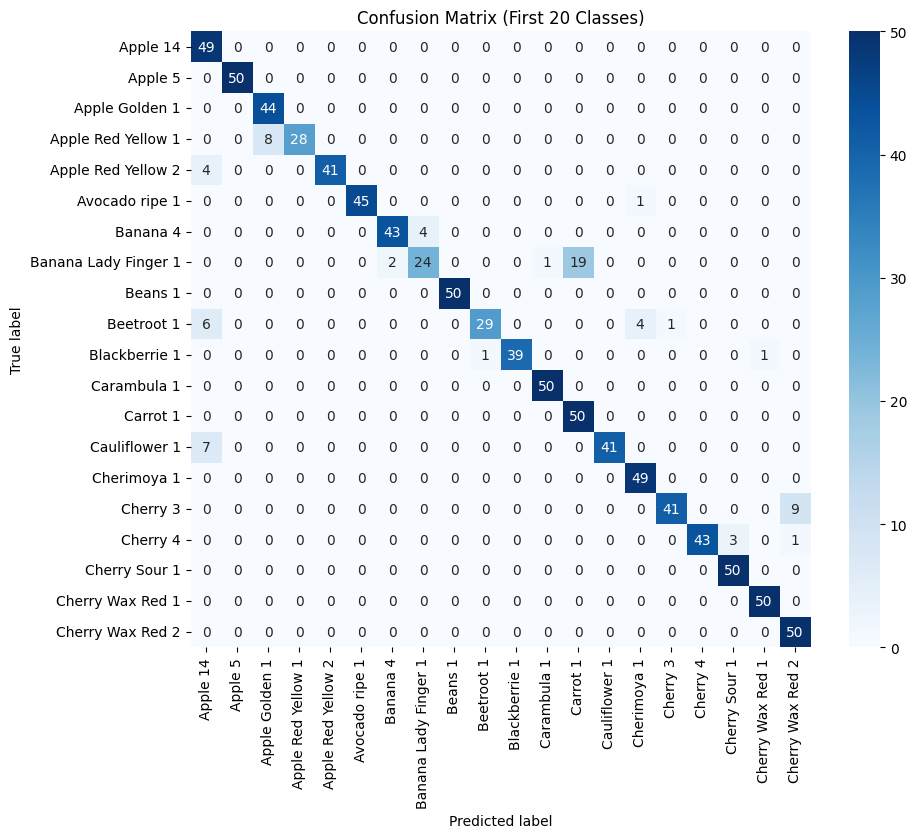

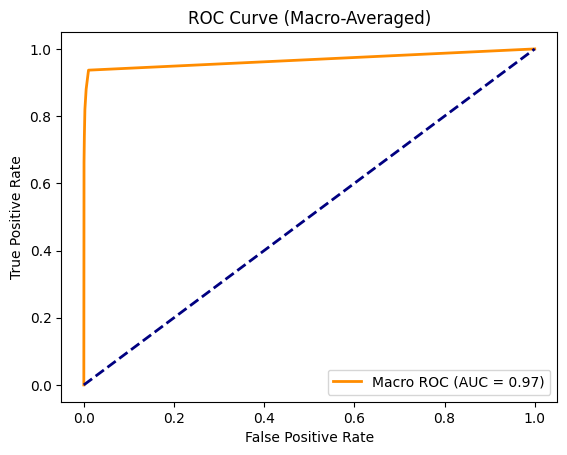

In [ ]:
saved_model_name = "knn_model"

saved_model = joblib.load(f"{saved_model_name}.joblib")
y_pred = saved_model.predict(X_val_flat)
acc = accuracy_score(y_val_enc, y_pred)

# Classification report
print(f"Validation accuracy: {acc:.4f}")
selected_classes = le.classes_[:20]
selected_labels = [le.transform([c])[0] for c in selected_classes]
print(classification_report(
    y_val_enc,
    y_pred,
    labels=selected_labels,
    target_names=selected_classes
))

subset_classes = le.classes_[:20]

mat_subset = confusion_matrix(
    y_val_enc, y_pred, 
    labels=range(len(subset_classes))
)

# Confusion matrix 
plt.figure(figsize=(10, 8))
sns.heatmap(mat_subset, cmap="Blues", annot=True, fmt="d", 
            xticklabels=subset_classes, 
            yticklabels=subset_classes)

plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix (First 20 Classes)')
plt.show()

# ROC Curve
y_val_bin = label_binarize(y_val_enc, classes=np.arange(len(le.classes_)))
y_proba = saved_model.predict_proba(X_val_flat)

fpr, tpr, _ = roc_curve(y_val_bin.ravel(), y_proba.ravel())
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"Macro ROC (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Macro-Averaged)")
plt.legend(loc="lower right")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    n_jobs=-1,
    random_state=42
)

for metric_name, scorer in scorers.items():
    scores = cross_val_score(rf_clf, X_train_flat, y_train_enc, cv=skf, scoring=scorer, n_jobs=-1)
    print(f"{metric_name}: {scores.mean():.4f} ± {scores.std():.4f}")

rf_clf.fit(X_train_flat, y_train_enc)
joblib.dump(rf_clf, "rf_model.joblib")

Random Forest Accuracy: 0.9464
                        precision    recall  f1-score   support

              Apple 14       0.94      1.00      0.97        50
               Apple 5       0.98      1.00      0.99        50
        Apple Golden 1       0.80      0.88      0.84        50
    Apple Red Yellow 1       1.00      0.62      0.77        50
    Apple Red Yellow 2       1.00      1.00      1.00        50
        Avocado ripe 1       1.00      1.00      1.00        50
              Banana 4       0.98      1.00      0.99        50
  Banana Lady Finger 1       1.00      0.68      0.81        50
               Beans 1       1.00      1.00      1.00        50
            Beetroot 1       0.72      0.78      0.75        50
         Blackberrie 1       0.96      0.98      0.97        50
           Carambula 1       0.89      1.00      0.94        50
              Carrot 1       0.85      1.00      0.92        50
         Cauliflower 1       0.88      1.00      0.93        50
        

Validation accuracy: 0.9464
                      precision    recall  f1-score   support

            Apple 14       0.94      1.00      0.97        50
             Apple 5       0.98      1.00      0.99        50
      Apple Golden 1       0.80      0.88      0.84        50
  Apple Red Yellow 1       1.00      0.62      0.77        50
  Apple Red Yellow 2       1.00      1.00      1.00        50
      Avocado ripe 1       1.00      1.00      1.00        50
            Banana 4       0.98      1.00      0.99        50
Banana Lady Finger 1       1.00      0.68      0.81        50
             Beans 1       1.00      1.00      1.00        50
          Beetroot 1       0.72      0.78      0.75        50
       Blackberrie 1       0.96      0.98      0.97        50
         Carambula 1       0.89      1.00      0.94        50
            Carrot 1       0.85      1.00      0.92        50
       Cauliflower 1       0.88      1.00      0.93        50
         Cherimoya 1       0.93      1.00

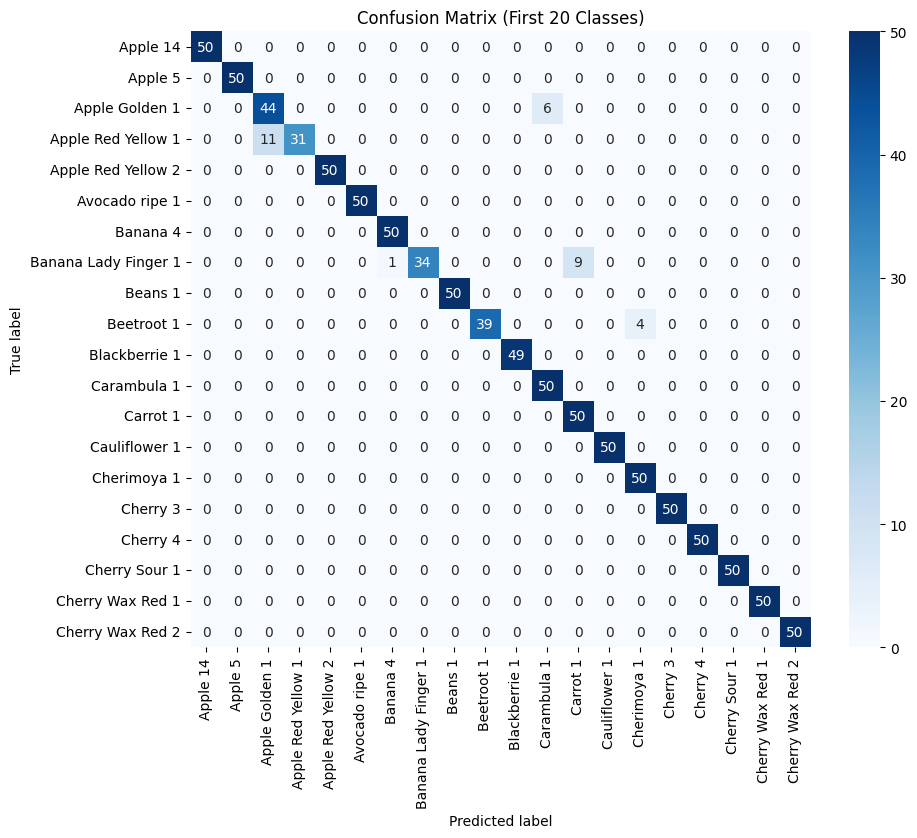

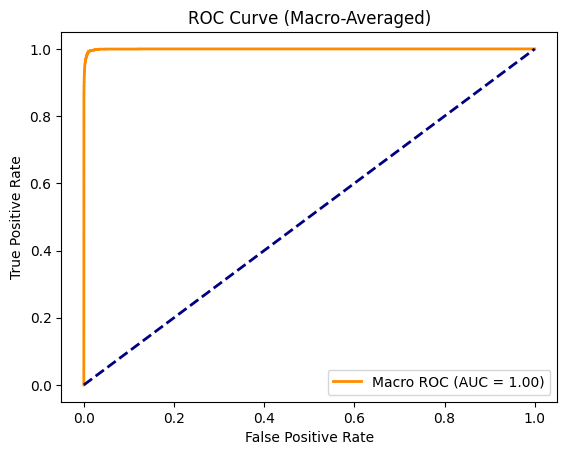

In [ ]:
saved_model_name = "rf_model"

saved_model = joblib.load(f"{saved_model_name}.joblib")
y_pred = saved_model.predict(X_val_flat)
acc = accuracy_score(y_val_enc, y_pred)

# Classification report
print(f"Validation accuracy: {acc:.4f}")
selected_classes = le.classes_[:20]
selected_labels = [le.transform([c])[0] for c in selected_classes]
print(classification_report(
    y_val_enc,
    y_pred,
    labels=selected_labels,
    target_names=selected_classes
))

subset_classes = le.classes_[:20]

mat_subset = confusion_matrix(
    y_val_enc, y_pred, 
    labels=range(len(subset_classes))
)

# Confusion matrix 
plt.figure(figsize=(10, 8))
sns.heatmap(mat_subset, cmap="Blues", annot=True, fmt="d", 
            xticklabels=subset_classes, 
            yticklabels=subset_classes)

plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix (First 20 Classes)')
plt.show()

# ROC Curve
y_val_bin = label_binarize(y_val_enc, classes=np.arange(len(le.classes_)))
y_proba = saved_model.predict_proba(X_val_flat)

fpr, tpr, _ = roc_curve(y_val_bin.ravel(), y_proba.ravel())
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"Macro ROC (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Macro-Averaged)")
plt.legend(loc="lower right")
plt.show()